# Danish House Prices — Real vs. Nominal


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from house_price_analysis import DanishHousePrices

%load_ext autoreload
%autoreload 2


## 1. Danish House Prices

In [3]:
analyzer = DanishHousePrices()

### Question 1.1

In [4]:
prices = analyzer.fetch_house_prices()

In [5]:
# Inspect the data structure
print(f"Data shape: {prices.shape}")
print(f"Time period: {prices.index[0]} to {prices.index[-1]}")
print(f"\nFirst few rows:")
prices.head()

Data shape: (135, 16)
Time period: 1992-01-01 00:00:00 to 2025-07-01 00:00:00

First few rows:


OMRÅDE,All Denmark,Province Byen København,Province Fyn,Province Københavns omegn,Province Nordjylland,Province Nordsjælland,Province Sydjylland,Province Vest- og Sydsjælland,Province Vestjylland,Province Østjylland,Province Østsjælland,Region Hovedstaden,Region Midtjylland,Region Nordjylland,Region Sjælland,Region Syddanmark
time,,,,,,,,,,,,,,,,
1992-01-01,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1992-04-01,100.000000,101.6,101.086957,98.701299,100.589971,99.473684,99.706745,100.000000,99.50,100.000000,100.000000,100.000000,100.000000,100.589971,100.000000,100.000000
1992-07-01,97.959184,101.6,98.913043,96.103896,97.345133,96.842105,99.120235,97.419355,97.25,100.000000,98.048780,97.546012,98.947368,97.345133,97.735849,99.038462
1992-10-01,95.510204,96.0,96.739130,94.805195,96.460177,93.684211,97.067449,94.516129,95.75,96.296296,94.634146,94.478528,96.140351,96.460177,94.716981,96.794872
1993-01-01,94.285714,96.0,97.101449,92.857143,94.100295,92.631579,95.601173,93.548387,94.50,94.238683,93.170732,93.251534,94.385965,94.100295,93.584906,96.153846


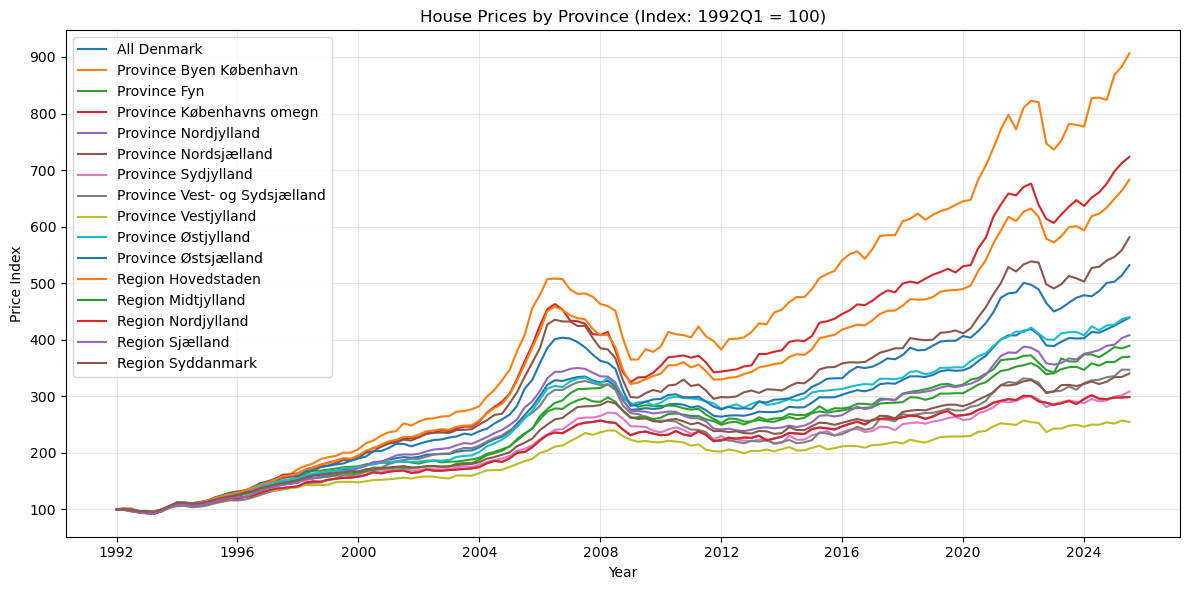

In [6]:
analyzer.plot_nominal_prices();

In [7]:
# Calculate summary statistics for price growth
price_growth = prices.iloc[-1] - prices.iloc[0]
print("Price growth by region (index points):")
print(price_growth.sort_values(ascending=False))
print(f"\nMean growth: {price_growth.mean():.2f}")
print(f"Std deviation: {price_growth.std():.2f}")

Price growth by region (index points):
OMRÅDE
Province Byen København          806.400000
Province Københavns omegn        623.376623
Region Hovedstaden               582.822086
Province Nordsjælland            481.052632
Province Østsjælland             431.707317
Province Østjylland              339.917695
All Denmark                      338.775510
Region Sjælland                  307.924528
Province Fyn                     289.130435
Region Midtjylland               269.824561
Province Vest- og Sydsjælland    246.774194
Region Syddanmark                240.064103
Province Sydjylland              208.211144
Province Nordjylland             198.525074
Region Nordjylland               198.525074
Province Vestjylland             154.500000
dtype: float64

Mean growth: 357.35
Std deviation: 182.45


The plot shows significant regional variation in nominal house price development since 1992. Copenhagen region shows the strongest growth, with prices increasing by over 300 index points. Regions like North Jutland and Bornholm show more modest growth. The 2008 financial crisis is visible as a sharp downturn across all regions, with recovery beginning around 2012-2013.

### Question 1.2

In [8]:
cpi = analyzer.fetch_cpi()

In [9]:
real = analyzer.calculate_real_prices()

In [10]:
# Compare nominal vs real growth for Copenhagen
copenhagen_nominal = prices['Province Byen København'].iloc[-1] - prices['Province Byen København'].iloc[0]
copenhagen_real = real['Province Byen København'].iloc[-1] - real['Province Byen København'].iloc[0]

print(f"Copenhagen growth:")
print(f"  Nominal: {copenhagen_nominal:.2f} index points")
print(f"  Real: {copenhagen_real:.2f} index points")
print(f"  Inflation effect: {copenhagen_nominal - copenhagen_real:.2f} index points")

Copenhagen growth:
  Nominal: 806.40 index points
  Real: 380.29 index points
  Inflation effect: 426.11 index points


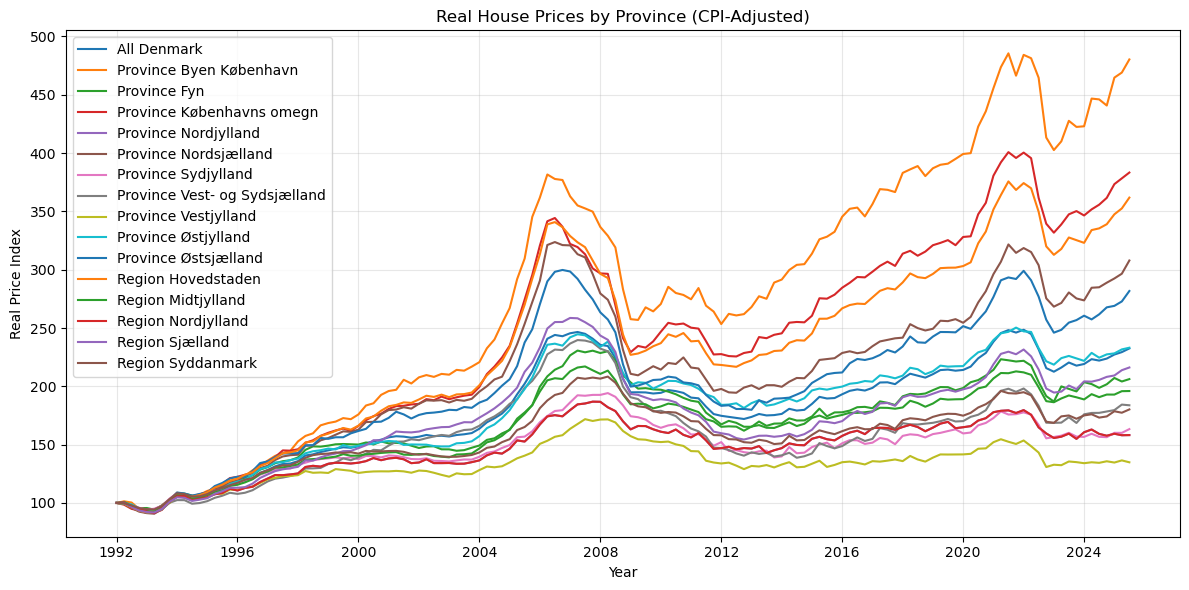

In [11]:
analyzer.plot_real_prices();

When adjusting for inflation, the real price growth is significantly lower than nominal growth. This shows that a substantial part of the nominal price increases simply reflects general inflation in the economy. The crisis impact appears more severe in real terms, with some regions experiencing prolonged periods below their pre-crisis real price levels. This indicates that housing has not universally been a strong inflation hedge in Denmark.

In [12]:
rankings = analyzer.rank_provinces()
rankings

OMRÅDE
Province Byen København          380.286663
Province Københavns omegn        283.305543
Region Hovedstaden               261.816352
Province Nordsjælland            207.890368
Province Østsjælland             181.743086
Province Østjylland              133.105254
All Denmark                      132.500028
Region Sjælland                  116.152593
Province Fyn                     106.193908
Region Midtjylland                95.964038
Province Vest- og Sydsjælland     83.750022
Region Syddanmark                 80.194454
Province Sydjylland               63.316087
Province Nordjylland              58.183596
Region Nordjylland                58.183596
Province Vestjylland              34.855423
dtype: float64

The ranking confirms Copenhagen as the strongest performing region, followed by other urban centers. The geographic pattern suggests that urbanization and economic centralization have been key drivers of house price growth in Denmark over this period.

### Question 1.3

Load data from BM010_houses.xlsx and analyze growth vs initial price levels

In [13]:
muni_data = analyzer.load_municipality_data('data/BM010_houses.xlsx')

In [14]:
# Explore municipality data
print(f"Number of municipalities: {len(muni_data)}")
print(f"Number of quarters: {len(muni_data.columns) - 1}")
print(f"\nSample data:")
muni_data.head()

Number of municipalities: 92
Number of quarters: 134

Sample data:


,Municipality,1992Q1,1992Q2,1992Q3,1992Q4,1993Q1,1993Q2,1993Q3,1993Q4,1994Q1,...,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2
0,København,5355.0,5451.0,5374.0,5171.0,5068.0,5186.0,5609.0,5519.0,5503.0,...,43538.0,46023.0,47651,48146.0,47769.0,51843,52011,54143.0,56588.0,56744.0
2,Dragør,6251.0,6472.0,6364.0,6246.0,6158.0,6438.0,6573.0,6261.0,5969.0,...,33809.0,33105.0,35803,33492.0,34092.0,35732,41012,36296.0,36214.0,40602.0
3,Tårnby,5747.0,6003.0,6075.0,5856.0,5275.0,5860.0,5976.0,5916.0,6196.0,...,30923.0,31249.0,33712,34524.0,32718.0,35569,34602,35882.0,36194.0,37924.0
4,Albertslund,5240.0,5408.0,5417.0,5341.0,5130.0,4773.0,5746.0,5492.0,5616.0,...,23417.0,23360.0,23703,24200.0,23486.0,24548,24941,26787.0,25764.0,26737.0
5,Ballerup,5696.0,6015.0,5771.0,5203.0,5925.0,5647.0,5813.0,6163.0,6132.0,...,28512.0,27256.0,29300,29008.0,29088.0,30221,30813,29735.0,33278.0,35127.0


The scatter plot below examines the relationship between initial price levels and total price growth across municipalities. 

To avoid cluttering the plot, only municipalities that are either in the top 5 by growth OR top 5 by initial price are labeled. Since some municipalities appear in both categories, fewer than 10 labels may be shown.

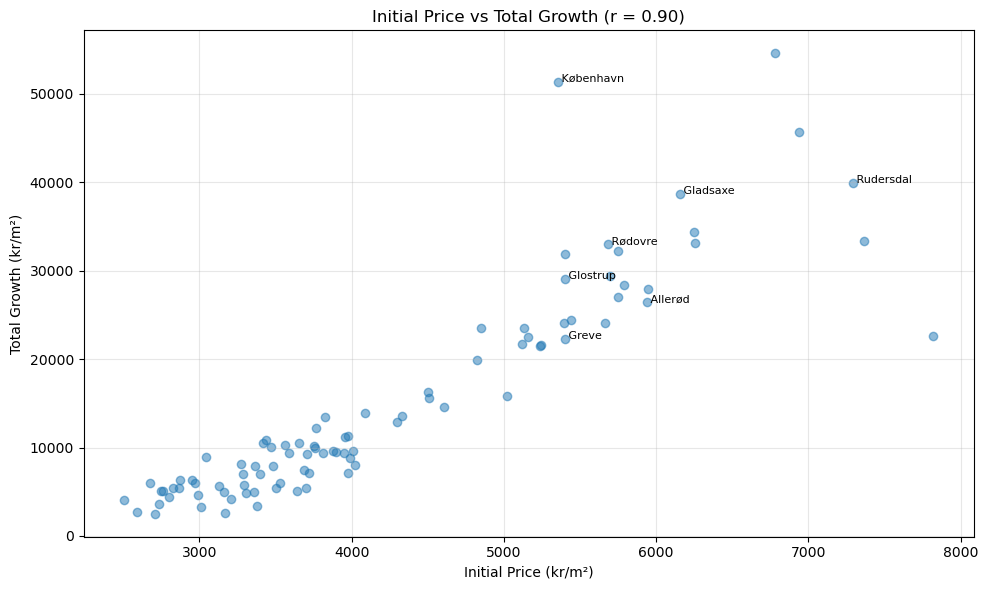

In [15]:
analyzer.plot_growth_vs_initial();

In [16]:
# Calculate correlation manually to show the calculation
quarters = [col for col in muni_data.columns if col != 'Municipality']
initial_prices = muni_data[quarters[0]]
final_prices = muni_data[quarters[-1]]
growth = final_prices - initial_prices

correlation = np.corrcoef(initial_prices, growth)[0, 1]
print(f"Correlation between initial price and growth: {correlation:.3f}")

if correlation > 0:
    print("Positive correlation: Expensive areas grew faster (divergence)")
else:
    print("Negative correlation: Cheaper areas caught up (convergence)")

Correlation between initial price and growth: 0.901
Positive correlation: Expensive areas grew faster (divergence)


The correlation coefficient reveals the relationship between initial price levels and subsequent growth. A positive correlation would suggest that expensive areas have become even more expensive (divergence), while a negative correlation would indicate convergence. The scatter pattern shows whether expensive municipalities in wealthy areas have experienced disproportionate growth, or whether cheaper areas have been catching up.

### Question 1.4

In [17]:
rolling = analyzer.calculate_rolling_average(window=4)

In [18]:
# Show example of rolling average for first municipality
print("Rolling average (4-quarter) for first municipality:")
print(f"Municipality: {rolling['Municipality'].iloc[0]}")
print(f"\nFirst 8 quarters of rolling averages:")
print(rolling.iloc[0, 1:9].values)

Rolling average (4-quarter) for first municipality:
Municipality: København

First 8 quarters of rolling averages:
[np.float64(nan) np.float64(nan) np.float64(nan) np.float64(5337.75)
 np.float64(5266.0) np.float64(5199.75) np.float64(5258.5)
 np.float64(5345.5)]


We calculate a 4-quarter backward rolling average to smooth out short-term fluctuations and identify longer-term trends. The plot below shows this for a sample of 8 municipalities to maintain readability.


Municipalities below pre-crisis peak: 16/92

Still below peak:
  - Gribskov
  - Halsnæs
  - Faxe
  - Guldborgsund
  - Kalundborg
  - Lolland
  - Næstved
  - Odsherred
  - Slagelse
  - Stevns
  - Vordingborg
  - Langeland
  - Haderslev
  - Hedensted
  - Norddjurs
  - Struer


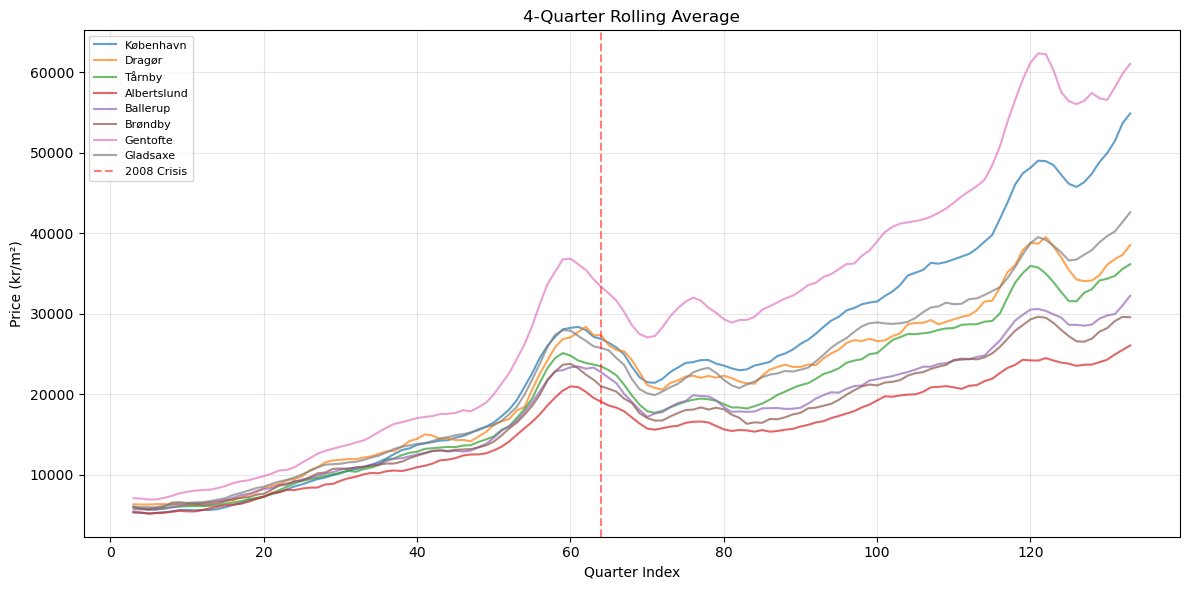

In [19]:
analyzer.analyze_crisis_recovery();

In [20]:
# Calculate recovery statistics
quarters = [col for col in rolling.columns if col != 'Municipality']

# Find approximate 2008Q1 (60% through the data as approximation)
crisis_idx = int(len(quarters) * 0.6)

# Get pre-crisis peaks and current levels
pre_crisis_peaks = rolling[quarters[:crisis_idx]].max(axis=1)
current_levels = rolling[quarters[-1]]

# Identify municipalities below peak
still_below = rolling['Municipality'][current_levels < pre_crisis_peaks]
recovered = rolling['Municipality'][current_levels >= pre_crisis_peaks]

print(f"Crisis recovery analysis:")
print(f"  Recovered: {len(recovered)} municipalities ({len(recovered)/len(rolling)*100:.1f}%)")
print(f"  Still below peak: {len(still_below)} municipalities ({len(still_below)/len(rolling)*100:.1f}%)")

Crisis recovery analysis:
  Recovered: 68 municipalities (73.9%)
  Still below peak: 24 municipalities (26.1%)


## Conclusion

This analysis of Danish house prices from 1992 onwards reveals several key findings:

1. Geographic Divergence: House prices have grown substantially more in urban centers, particularly Copenhagen, compared to peripheral regions. This reflects broader economic trends of centralization and urbanization in Denmark.

2. Inflation Impact: Real price growth is considerably lower than nominal growth, emphasizing the importance of inflation adjustment when evaluating housing as an investment. Housing has not universally served as a strong inflation hedge.

3. Crisis Legacy: The 2008 financial crisis had a profound and lasting impact. Many municipalities have still not recovered to their pre-crisis peak levels, creating significant wealth disparities across regions.

4. Policy Implications: The persistent divergence between urban and peripheral areas raises important questions about regional inequality, mobility, and the need for place-based economic policies to support struggling housing markets.

These patterns have important implications for homeowners, policymakers, and researchers studying wealth inequality and regional economic development in Denmark.

The rolling average reveals the persistence of the crisis impact. Municipalities that remain below their pre-2008 peaks are experiencing a "lost decade" in terms of housing wealth. This has significant implications for homeowners' wealth, mobility, and the local economy in these areas. The divergence between recovering and non-recovering municipalities highlights the uneven geographic impact of the financial crisis.